Decision Tree Accuracy: 0.7988826815642458


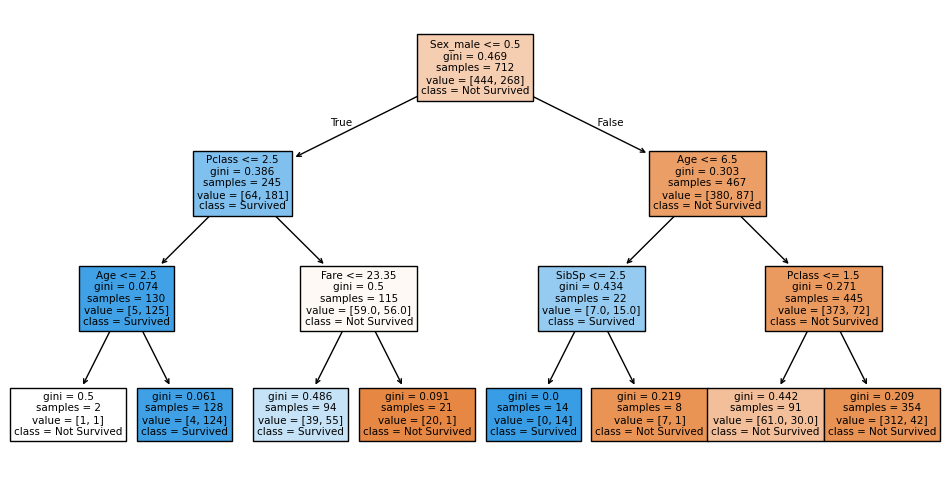

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load Titanic dataset
data = pd.read_csv(r'C:\Users\BHUVAN\OneDrive\Desktop\BOOKs & pdfs\B.Tech_3rd_Year\Sem-5_M26\IICT_Internship\Titanic\train.csv')

# Drop columns that are not useful or too messy
data = data.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Handle missing values
data["Age"].fillna(data["Age"].mean())
data["Embarked"].fillna(data["Embarked"].mode()[0])

# Convert categorical variables to numeric
data = pd.get_dummies(data, columns=["Sex", "Embarked"], drop_first=True)

# Split features and target
X = data.drop("Survived", axis=1)
y = data["Survived"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt.fit(X_train, y_train)

# Evaluate
y_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

# Visualize
plt.figure(figsize=(12,6))
plot_tree(dt, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

Random Forest Accuracy: 0.8212290502793296
Sex_male      0.451544
Fare          0.164370
Pclass        0.135733
Age           0.120003
SibSp         0.054989
Parch         0.034259
Embarked_S    0.028678
Embarked_Q    0.010424
dtype: float64


In [11]:
import numpy as np

# Detect missing values
missing_summary = data.isnull().sum()
print("Missing Values:\n", missing_summary)

# Detect outliers using IQR
Q1 = data['Fare'].quantile(0.25)
Q3 = data['Fare'].quantile(0.75)
IQR = Q3 - Q1
outliers = data[(data['Fare'] < (Q1 - 1.5 * IQR)) | (data['Fare'] > (Q3 + 1.5 * IQR))]
print("Outliers detected:\n", outliers[['PassengerId', 'Fare']])


Missing Values:
 Survived        0
Pclass          0
Age           177
SibSp           0
Parch           0
Fare            0
Sex_male        0
Embarked_Q      0
Embarked_S      0
dtype: int64


KeyError: "['PassengerId'] not in index"